# Modelado — Fase 4 CRISP-DM

Entrena y evalúa modelos de clasificación multiclase sobre el dataset minuto a minuto.

**Referencia de baseline:** predecir siempre `home_win` (clase mayoritaria) da ~47 % de accuracy. Cualquier modelo útil debe superarlo con claridad.

**Target:** `final_result` ∈ {`home_win`, `draw`, `away_win`}  
**Features:** 48 variables de entrada.  
**Split:** temporal por temporada — las más recientes (≥ 20 % de partidos) van a test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    classification_report, ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid", palette="muted")

FEATURES_PATH = "../datasets/match_minute_features.csv"
MODELS_DIR    = Path("../models")
FIGS_DIR      = Path("../assets/figuras/modeling")
MODELS_DIR.mkdir(exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP   = {"home_win": 0, "draw": 1, "away_win": 2}
LABEL_NAMES = ["home_win", "draw", "away_win"]
RANDOM_STATE = 42

## 1. Carga y definición de features

In [2]:
df = pd.read_csv(FEATURES_PATH, low_memory=False)

META_COLS    = ["match_id", "competition_name", "season_name", "home_team", "away_team"]
# minute is kept in the CSV as a row identifier but excluded from features:
# it is exactly 90 - minutes_remaining (r = -1.0) and carries no independent signal.
EXCLUDE_COLS = ["minute"]
TARGET_COL   = "final_result"
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + EXCLUDE_COLS + [TARGET_COL]]

n_rows    = len(df)
n_matches = df["match_id"].nunique()
n_feats   = len(FEATURE_COLS)
print(f"Filas:    {n_rows:,}")
print(f"Partidos: {n_matches:,}")
print(f"Features: {n_feats}")
print(f"\n{FEATURE_COLS}")

Filas:    311,760
Partidos: 3,464
Features: 48

['goals_home', 'shots_home', 'shots_on_target_home', 'shots_in_box_home', 'passes_home', 'pressures_home', 'duels_won_home', 'clearances_home', 'blocks_home', 'carries_home', 'yellow_cards_home', 'red_cards_home', 'attacks_third_home', 'xg_home', 'xg_last15_home', 'shots_last15_home', 'pressures_last15_home', 'goals_away', 'shots_away', 'shots_on_target_away', 'shots_in_box_away', 'passes_away', 'pressures_away', 'duels_won_away', 'clearances_away', 'blocks_away', 'carries_away', 'yellow_cards_away', 'red_cards_away', 'attacks_third_away', 'xg_away', 'xg_last15_away', 'shots_last15_away', 'pressures_last15_away', 'score_diff', 'xg_diff', 'shots_diff', 'possession_home', 'pass_completion_home', 'pass_completion_away', 'minutes_remaining', 'players_diff', 'total_goals', 'xg_per_shot_home', 'xg_per_shot_away', 'goals_minus_xg_home', 'goals_minus_xg_away', 'is_womens']


## 2. Split temporal por temporada

Se ordenan los partidos por año de inicio de temporada. Las temporadas más recientes que suman ≥ 20 % de los partidos forman el conjunto de test. El split se hace **a nivel de partido** — las 90 filas de cada partido van íntegras a train o a test.

In [3]:
matches = df.drop_duplicates("match_id")[["match_id", "season_name", "final_result"]].copy()

# Handles both "YYYY/YYYY" and single-year "YYYY" formats
matches["season_year"] = pd.to_numeric(matches["season_name"].str[:4], errors="coerce")
matches = matches.dropna(subset=["season_year"])
matches["season_year"] = matches["season_year"].astype(int)
matches = matches.sort_values("season_year").reset_index(drop=True)

n_test   = int(len(matches) * 0.20)
test_ids  = set(matches.tail(n_test)["match_id"])
train_ids = set(matches.head(len(matches) - n_test)["match_id"])

train = df[df["match_id"].isin(train_ids)]
test  = df[df["match_id"].isin(test_ids)]

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL].map(LABEL_MAP)
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET_COL].map(LABEL_MAP)

train_years = sorted(matches[matches["match_id"].isin(train_ids)]["season_year"].unique())
test_years  = sorted(matches[matches["match_id"].isin(test_ids)]["season_year"].unique())

print(f"Train: {len(train_ids):>5} partidos | {len(X_train):>7,} filas | años: {train_years[0]}-{train_years[-1]}")
print(f"Test:  {len(test_ids):>5} partidos | {len(X_test):>7,} filas | años: {test_years[0]}-{test_years[-1]}")
test_season_names = sorted(matches[matches["match_id"].isin(test_ids)]["season_name"].unique())
print(f"\nTemporadas en test: {test_season_names}")

Train:  2772 partidos | 249,480 filas | años: 1958-2020
Test:    692 partidos |  62,280 filas | años: 2020-2025

Temporadas en test: ['2020', '2020/2021', '2021/2022', '2022', '2022/2023', '2023', '2023/2024', '2024', '2025']


## 3. Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
print("Entrenamiento completado.")

Entrenamiento completado.


## 4. Métricas de evaluación

In [5]:
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)

acc      = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
logloss  = log_loss(y_test, y_pred_prob)

print(f"Accuracy:  {acc:.4f}  (objetivo >= 0.70)")
print(f"Macro-F1:  {macro_f1:.4f}")
print(f"Log-loss:  {logloss:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

Accuracy:  0.6599  (objetivo >= 0.70)
Macro-F1:  0.5916
Log-loss:  0.7691

              precision    recall  f1-score   support

    home_win       0.67      0.84      0.75     26730
        draw       0.59      0.23      0.33     15120
    away_win       0.66      0.74      0.70     20430

    accuracy                           0.66     62280
   macro avg       0.64      0.60      0.59     62280
weighted avg       0.65      0.66      0.63     62280



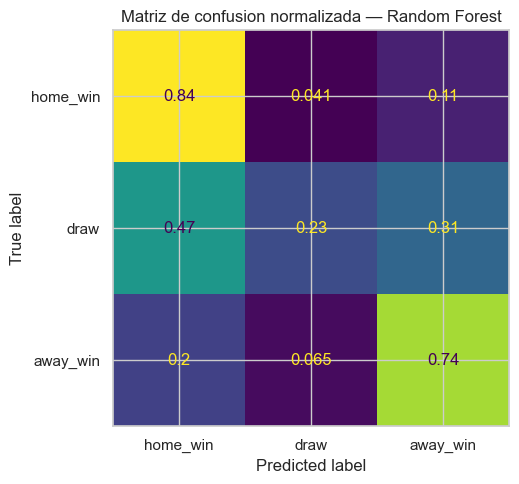

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=LABEL_NAMES,
    normalize="true",
    ax=ax,
    colorbar=False,
)
ax.set_title("Matriz de confusion normalizada — Random Forest")
plt.tight_layout()
plt.savefig(FIGS_DIR / "confusion_rf.pdf", bbox_inches="tight")
plt.show()

## 5. Accuracy por minuto

Métrica diferencial del trabajo: muestra cómo mejora la predicción conforme avanza el partido.

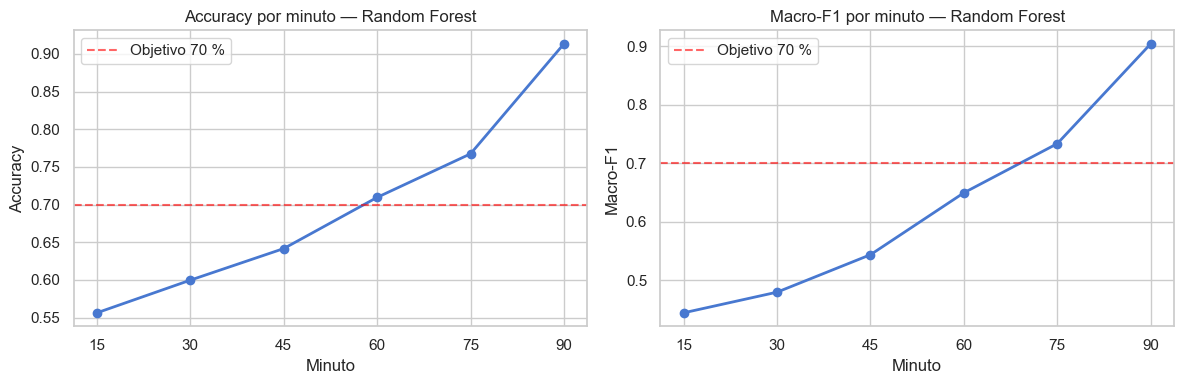

 minute  accuracy  macro_f1  n_samples
     15  0.556358  0.444209        692
     30  0.599711  0.479518        692
     45  0.641618  0.543512        692
     60  0.709538  0.649321        692
     75  0.767341  0.733294        692
     90  0.913295  0.903867        692


In [7]:
CHECKPOINTS = [15, 30, 45, 60, 75, 90]
minute_vals = test["minute"].values

rows = []
for m in CHECKPOINTS:
    mask = minute_vals == m
    rows.append({
        "minute":    m,
        "accuracy":  accuracy_score(y_test[mask], y_pred[mask]),
        "macro_f1":  f1_score(y_test[mask], y_pred[mask], average="macro"),
        "n_samples": int(mask.sum()),
    })

minute_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    ax.plot(minute_df["minute"], minute_df[col], marker="o", linewidth=2)
    ax.axhline(0.70, color="red", linestyle="--", alpha=0.6, label="Objetivo 70 %")
    ax.set_xlabel("Minuto")
    ax.set_ylabel(label)
    ax.set_title(f"{label} por minuto — Random Forest")
    ax.set_xticks(CHECKPOINTS)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / "accuracy_por_minuto_rf.pdf", bbox_inches="tight")
plt.show()

print(minute_df.to_string(index=False))

## 6. Importancia de features

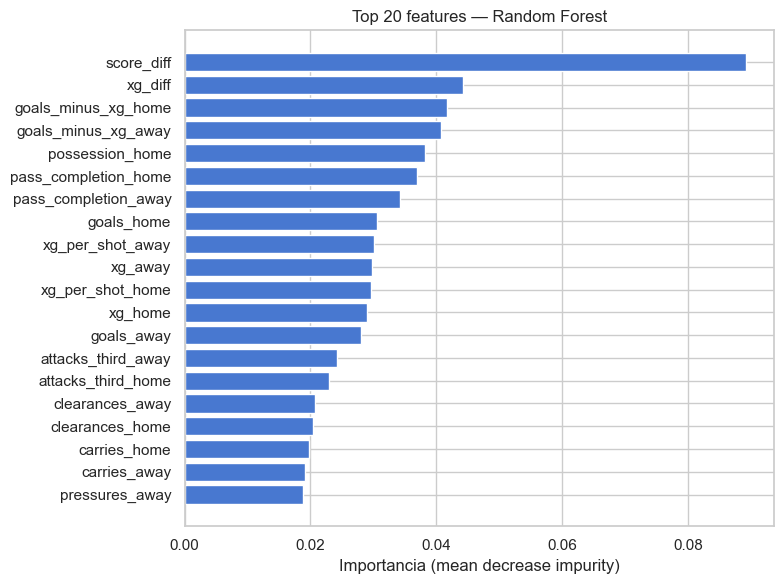

score_diff              0.0892
xg_diff                 0.0443
goals_minus_xg_home     0.0417
goals_minus_xg_away     0.0407
possession_home         0.0382
pass_completion_home    0.0369
pass_completion_away    0.0342
goals_home              0.0306
xg_per_shot_away        0.0301
xg_away                 0.0298
dtype: float64


In [8]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top20 = importances.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20.index[::-1], top20.values[::-1])
ax.set_xlabel("Importancia (mean decrease impurity)")
ax.set_title("Top 20 features — Random Forest")
plt.tight_layout()
plt.savefig(FIGS_DIR / "feature_importance_rf.pdf", bbox_inches="tight")
plt.show()

print(importances.head(10).round(4))

## 7. Guardado del modelo

In [9]:
model_path = MODELS_DIR / "random_forest.pkl"
joblib.dump(rf, model_path)
print(f"Modelo guardado en {model_path}")

Modelo guardado en ..\models\random_forest.pkl


## 8. XGBoost

In [10]:
sample_weights = compute_sample_weight("balanced", y_train)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    importance_type="gain",
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0,
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
print("Entrenamiento completado.")

Entrenamiento completado.


## 9. Metricas de evaluacion — XGBoost

In [11]:
y_pred_xgb      = xgb_model.predict(X_test)
y_pred_prob_xgb = xgb_model.predict_proba(X_test)

acc_xgb      = accuracy_score(y_test, y_pred_xgb)
macro_f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
logloss_xgb  = log_loss(y_test, y_pred_prob_xgb)

print(f"Accuracy:  {acc_xgb:.4f}  (objetivo >= 0.70)")
print(f"Macro-F1:  {macro_f1_xgb:.4f}")
print(f"Log-loss:  {logloss_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=LABEL_NAMES))

Accuracy:  0.6479  (objetivo >= 0.70)
Macro-F1:  0.6128
Log-loss:  0.7737

              precision    recall  f1-score   support

    home_win       0.74      0.74      0.74     26730
        draw       0.46      0.38      0.42     15120
    away_win       0.64      0.72      0.68     20430

    accuracy                           0.65     62280
   macro avg       0.61      0.62      0.61     62280
weighted avg       0.64      0.65      0.64     62280



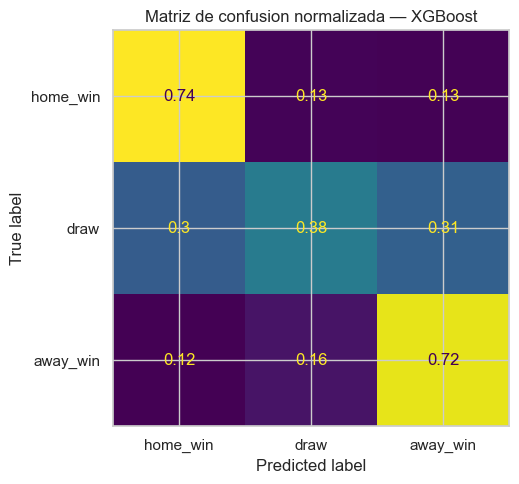

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=LABEL_NAMES,
    normalize="true",
    ax=ax,
    colorbar=False,
)
ax.set_title("Matriz de confusion normalizada — XGBoost")
plt.tight_layout()
plt.savefig(FIGS_DIR / "confusion_xgb.pdf", bbox_inches="tight")
plt.show()

## 10. Accuracy por minuto — XGBoost

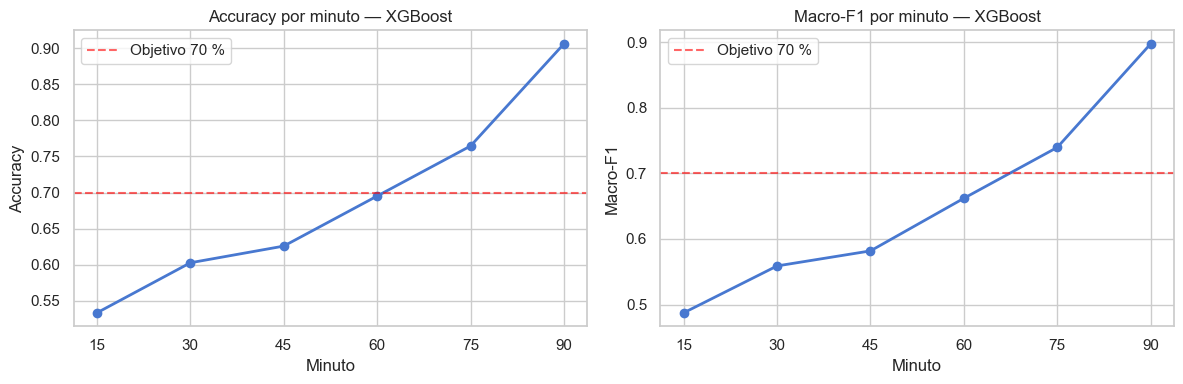

 minute  accuracy  macro_f1  n_samples
     15  0.533237  0.487504        692
     30  0.602601  0.558924        692
     45  0.625723  0.581840        692
     60  0.695087  0.661991        692
     75  0.764451  0.739516        692
     90  0.906069  0.897267        692


In [13]:
rows_xgb = []
for m in CHECKPOINTS:
    mask = minute_vals == m
    rows_xgb.append({
        "minute":    m,
        "accuracy":  accuracy_score(y_test[mask], y_pred_xgb[mask]),
        "macro_f1":  f1_score(y_test[mask], y_pred_xgb[mask], average="macro"),
        "n_samples": int(mask.sum()),
    })

minute_df_xgb = pd.DataFrame(rows_xgb)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    ax.plot(minute_df_xgb["minute"], minute_df_xgb[col], marker="o", linewidth=2)
    ax.axhline(0.70, color="red", linestyle="--", alpha=0.6, label="Objetivo 70 %")
    ax.set_xlabel("Minuto")
    ax.set_ylabel(label)
    ax.set_title(f"{label} por minuto — XGBoost")
    ax.set_xticks(CHECKPOINTS)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / "accuracy_por_minuto_xgb.pdf", bbox_inches="tight")
plt.show()

print(minute_df_xgb.to_string(index=False))

## 11. Importancia de features — XGBoost

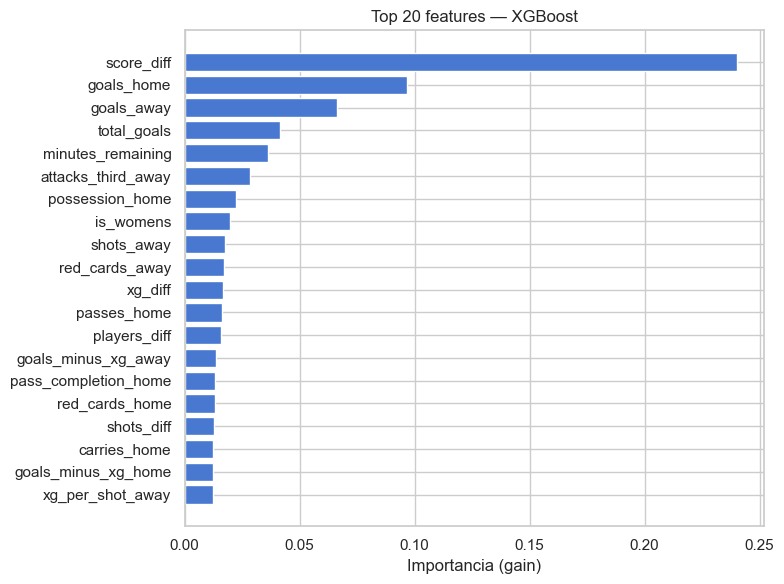

score_diff            0.2401
goals_home            0.0966
goals_away            0.0662
total_goals           0.0413
minutes_remaining     0.0361
attacks_third_away    0.0285
possession_home       0.0222
is_womens             0.0197
shots_away            0.0176
red_cards_away        0.0170
dtype: float32


In [14]:
importances_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top20_xgb = importances_xgb.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_xgb.index[::-1], top20_xgb.values[::-1])
ax.set_xlabel("Importancia (gain)")
ax.set_title("Top 20 features — XGBoost")
plt.tight_layout()
plt.savefig(FIGS_DIR / "feature_importance_xgb.pdf", bbox_inches="tight")
plt.show()

print(importances_xgb.head(10).round(4))

In [15]:
model_path_xgb = MODELS_DIR / "xgboost.pkl"
joblib.dump(xgb_model, model_path_xgb)
print(f"Modelo guardado en {model_path_xgb}")

Modelo guardado en ..\models\xgboost.pkl


## 12. Comparacion de modelos

               Accuracy  Macro-F1  Log-loss
Modelo                                     
Random Forest    0.6599    0.5916    0.7691
XGBoost          0.6479    0.6128    0.7737


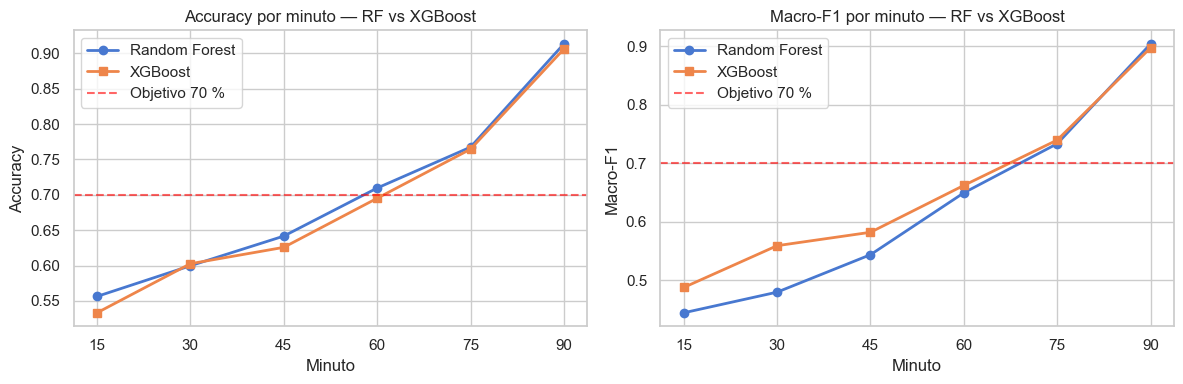

In [16]:
comparison = pd.DataFrame({
    "Modelo":    ["Random Forest", "XGBoost"],
    "Accuracy":  [acc,      acc_xgb],
    "Macro-F1":  [macro_f1, macro_f1_xgb],
    "Log-loss":  [logloss,  logloss_xgb],
}).set_index("Modelo")

print(comparison.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    ax.plot(minute_df["minute"],     minute_df[col],     marker="o", linewidth=2, label="Random Forest")
    ax.plot(minute_df_xgb["minute"], minute_df_xgb[col], marker="s", linewidth=2, label="XGBoost")
    ax.axhline(0.70, color="red", linestyle="--", alpha=0.6, label="Objetivo 70 %")
    ax.set_xlabel("Minuto")
    ax.set_ylabel(label)
    ax.set_title(f"{label} por minuto — RF vs XGBoost")
    ax.set_xticks(CHECKPOINTS)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / "comparison_rf_xgb.pdf", bbox_inches="tight")
plt.show()